In [2]:
import manim as mn
from manim import *

config.media_width = "75%"
config.verbosity = "WARNING"

print(mn.__version__)

0.20.1


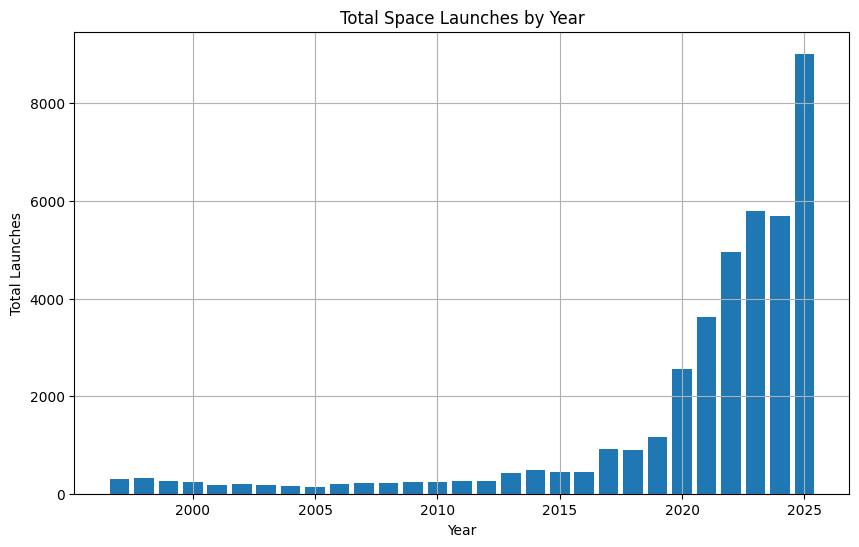

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
yearlylaunchdata = pd.read_csv('yearlylaunchdata.csv')
plt.figure(figsize=(10, 6))

by_year = yearlylaunchdata.groupby('Year').sum()[40:]
by_year.drop(columns=['Entity', 'Code'], inplace=True)
plt.bar(by_year.index, by_year['Annual number of objects launched into outer space'])
plt.xlabel('Year')
plt.ylabel('Total Launches')
plt.title('Total Space Launches by Year')
plt.grid()
plt.show()


Manim Community v0.20.1

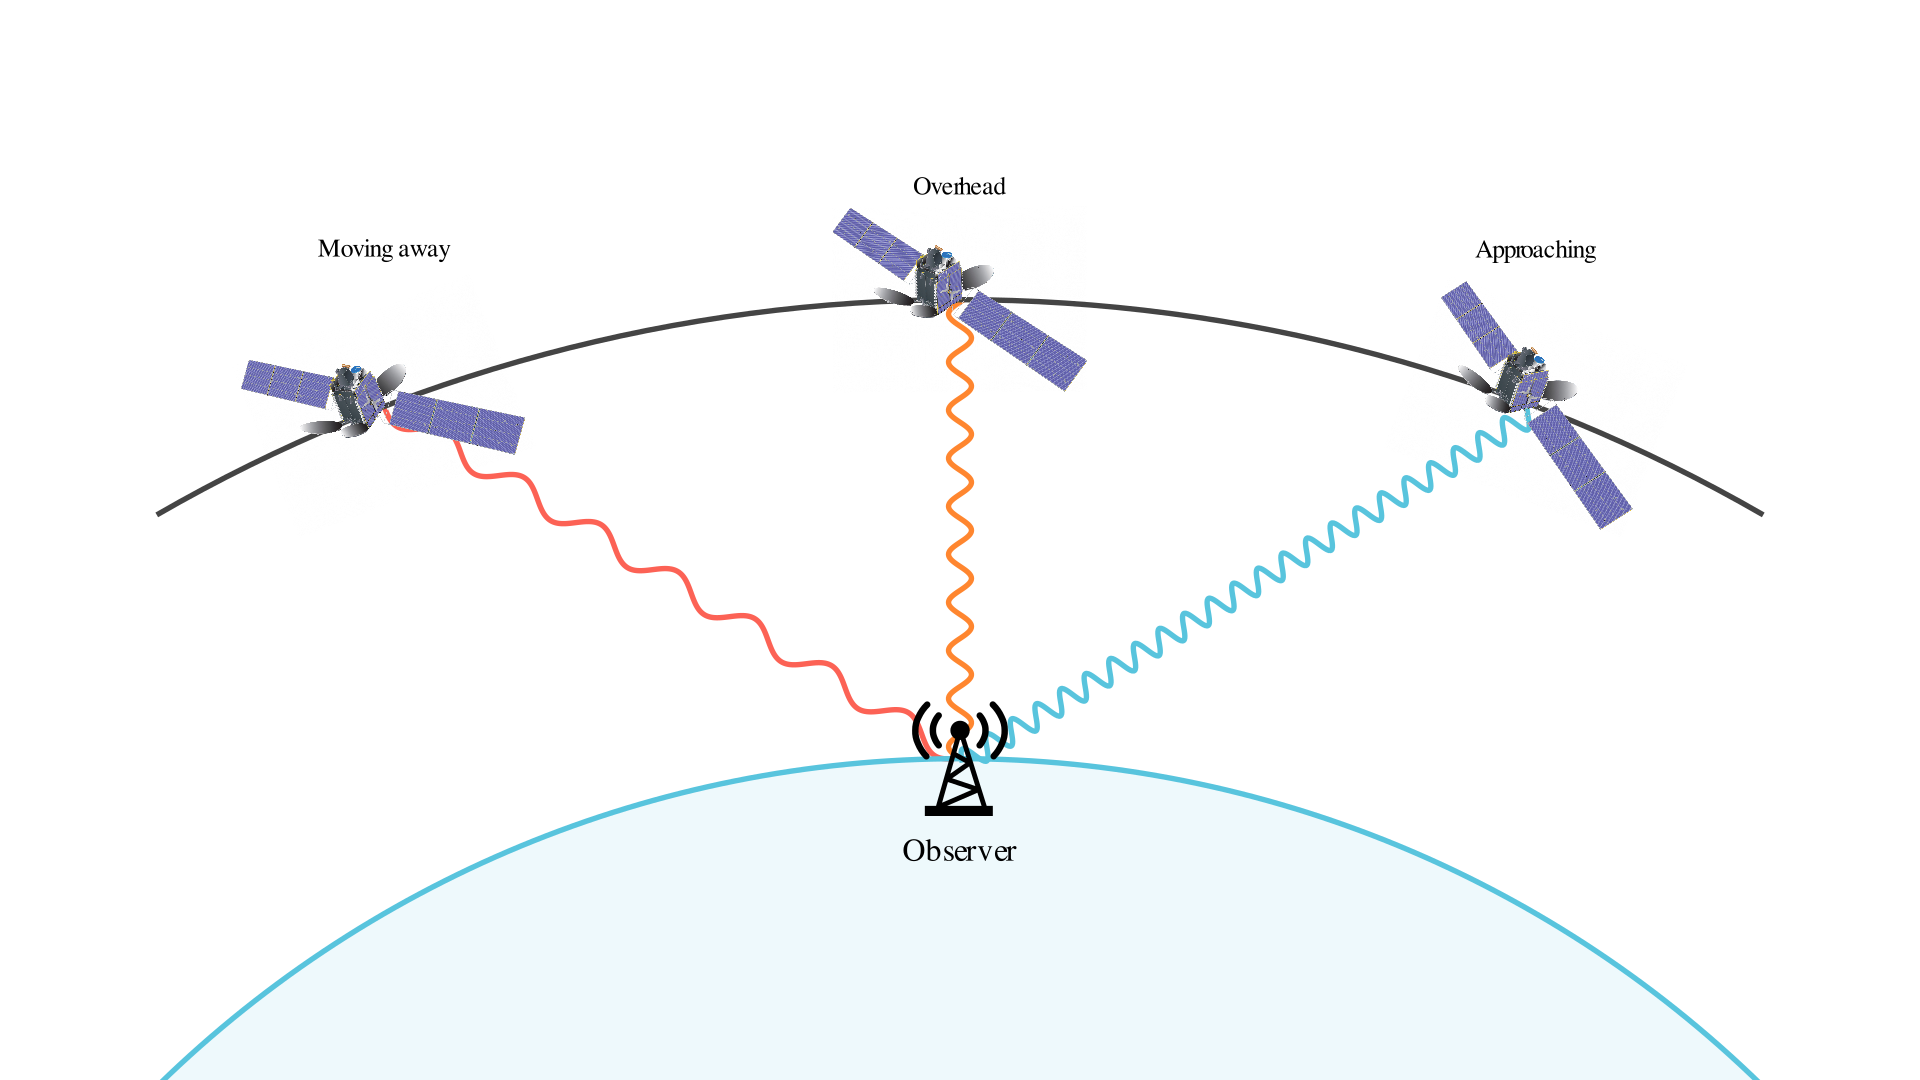

In [ ]:
%%manim -qh DopplerSlide

from manim import *
import numpy as np

class DopplerSlide(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        main_group = Group()

        earth = Circle(radius=10, color=BLUE, fill_opacity=0.1)
        earth.move_to(DOWN * 12)
        
        observer = SVGMobject("ant.svg").scale(0.5)
        observer.move_to(earth.get_top())
        obs_label = Text("Observer", color=BLACK, font_size=20).next_to(observer, DOWN, buff=0.2)
        
        orbit = Arc(
            radius=14, 
            angle=PI/3, 
            start_angle=PI/2 - PI/6, 
            arc_center=earth.get_center(), 
            color=DARK_GRAY
        ).set_style()

        proportions = [0.15, 0.5, 0.85]
        wave_freqs = [25, 15, 8]
        wave_colors = [BLUE, ORANGE, RED]
        labels = ["Approaching", "Overhead", "Moving away"]

        sat_group = Group()
        rf_group = Group()

        for p, freq, col, lbl in zip(proportions, wave_freqs, wave_colors, labels):

            sat_pos = orbit.point_from_proportion(p)

            pos_slightly_ahead = orbit.point_from_proportion(min(p + 0.01, 1.0))
            tangent_vector = pos_slightly_ahead - sat_pos
            angle = angle_of_vector(tangent_vector)

            satellite = ImageMobject("satellite.png").scale(0.1)
            satellite.move_to(sat_pos)
            satellite.rotate(angle)
            sat_label = Text(lbl, color=BLACK, font_size=16).next_to(satellite, UP, buff=0.1)

            link_line = Line(observer.get_center(), satellite.get_center())

            rf_wave = FunctionGraph(
                lambda x: 0.1 * np.sin(freq * x), 
                x_range=[0, link_line.get_length()],
                color=col
            )
            rf_wave.rotate(link_line.get_angle())
            rf_wave.move_to(link_line.get_center())

            sat_group.add(satellite, sat_label)
            rf_group.add(rf_wave)

        main_group.add(
            rf_group,
            earth, observer, obs_label, 
            orbit, sat_group,
    
        main_group.scale(0.85).shift(UP * 1.5)

        self.add(main_group)